In [25]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
from scipy import stats

**Q2.** 

We often study sample averages: It's one of the first statistics you calculate for any dataset. What is the distribution of the sample mean?

1. Draw `n = 32` values from `Uniform[-sqrt(3), sqrt(3)]`; these are your data. The choice of $\pm \sqrt{3}$ ensures each draw has mean 0 and variance 1.
2. For this sample, compute the mean and multiply by `np.sqrt(n)`.
3. Repeat the above process `b = 5_000` times and plot the ECDF.
4. What distribution does this approach as $n$ increases?

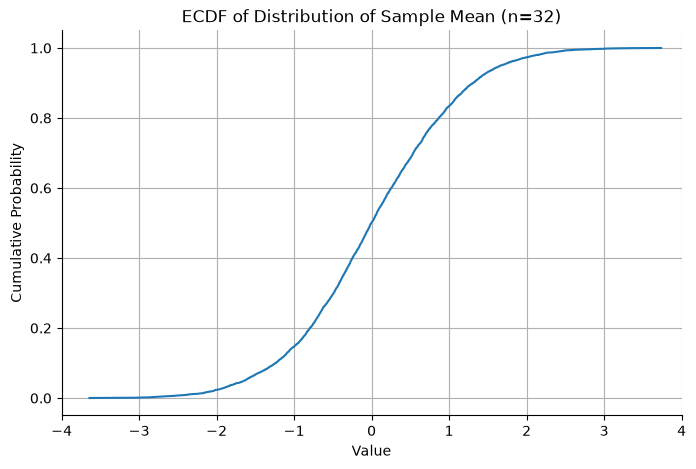

In [47]:
n = 32
b = 5000
values = []

for _ in range(b):
    draws = np.random.uniform(-np.sqrt(3), np.sqrt(3), n)
    sample_mean = np.mean(draws)
    value = np.sqrt(n) * sample_mean
    values.append(value)

ecdf = ECDF(values)

plt.plot(ecdf.x, ecdf.y, label='Simulated ECDF')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.title('ECDF of Distribution of Sample Mean (n=32)')
plt.grid(True)
plt.xlim((-4, 4))
plt.show()

The curve follows a normal distribution's CDF, having the classic S-shape and is centered at 0. The rescaled sample means converge to a Normal distribution as n grows.

**Q3.**

In reliability engineering, we are often concerned with the proportions of failures that occur. For example, the Challenger space shuttle exploded on January 28, 1986, when the primary and secondary o-rings failed. Floods often occur because too many levees or pumps are compromised. In this simulation, we have 40 units that each fail with probability p, and we want to study the distribution of the survivors.

1. Flip n = 40 coins, which each come up heads with probability p = 1/2 and tails with complementary probability.
2. From the final count of heads, subtract the expected number of heads, n * p.
3. Divide by the standard deviation sqrt( n * p * (1-p) ).
4. Repeat the above process b = 5_000 times and plot the ECDF.
5. What distribution does this approach as n increases?
6. How do the results change as you adjust p?

In [27]:
rng = np.random.default_rng(20260717)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [28]:
def ecdf_xy(samples):
    x = np.sort(np.asarray(samples))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


def plot_ecdf_vs_cdf(samples, cdf, grid=None, title="", xlabel="", discrete=False, logx=False):
    x, y = ecdf_xy(samples)
    fig, ax = plt.subplots()
    ax.step(x, y, where="post", lw=2, label="simulation ECDF")

    if grid is None:
        lo, hi = np.quantile(x, [0.001, 0.999])
        grid = np.linspace(lo, hi, 400)
    if discrete:
        ax.step(grid, cdf(grid), where="post", lw=2, label="scipy CDF")
    else:
        ax.plot(grid, cdf(grid), lw=2, label="scipy CDF")

    if logx:
        ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("cumulative probability")
    ax.legend()
    return ax


def show_quantiles(samples, dist, probs=(0.1, 0.25, 0.5, 0.75, 0.9)):
    return pd.DataFrame({
        "p": probs,
        "simulation": np.quantile(samples, probs),
        "scipy": dist.ppf(probs),
    })

**Original Graph**

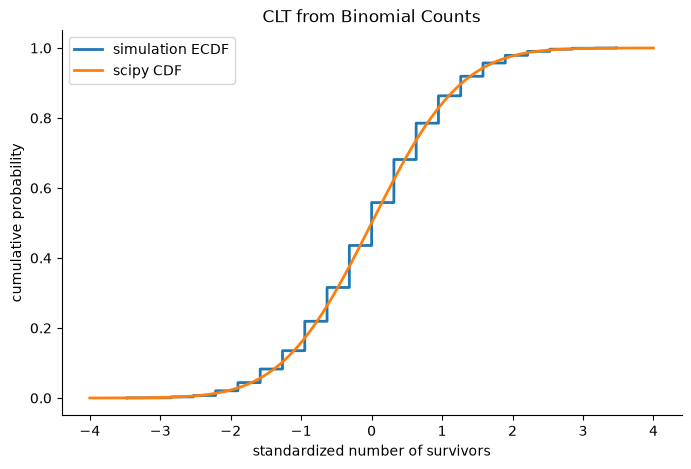

In [29]:
n = 40
p = 1 / 2
b = 5_000

counts = rng.binomial(n, p, size=b)

z_binom = (counts - n * p) / np.sqrt(n * p * (1 - p)) 

normal = stats.norm(0, 1)

plot_ecdf_vs_cdf(z_binom, normal.cdf, grid=np.linspace(-4, 4, 500), title="CLT from Binomial Counts", xlabel="standardized number of survivors")
plt.show()

This is the original graph with n = 40, and we can see that the ECDF aligns fairly well with the CDF. 

**What Happens When We Increase n? (5)**

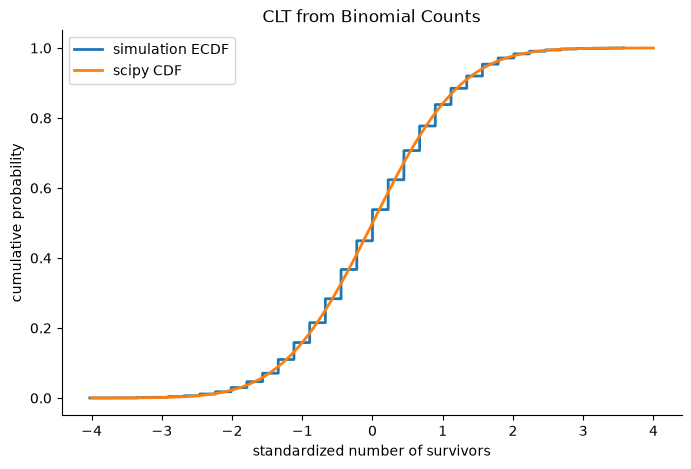

In [30]:
n = 80
p = 1 / 2
b = 5_000

counts = rng.binomial(n, p, size=b)

z_binom = (counts - n * p) / np.sqrt(n * p * (1 - p)) 

normal = stats.norm(0, 1) 

plot_ecdf_vs_cdf(z_binom, normal.cdf, grid=np.linspace(-4, 4, 500), title="CLT from Binomial Counts", xlabel="standardized number of survivors")
plt.show()

In this graph, n is doubled from 40 to 80. The steps immediately became smaller and closer to the CDF line. From this, I assume as n grows, the ECDF gets closer to the CDF. As n approaches infinity (which in normal ECDF experiments is not the case), the ECDF line aproaches the CDF line.

**What Happens With Different P-Values? (6)**

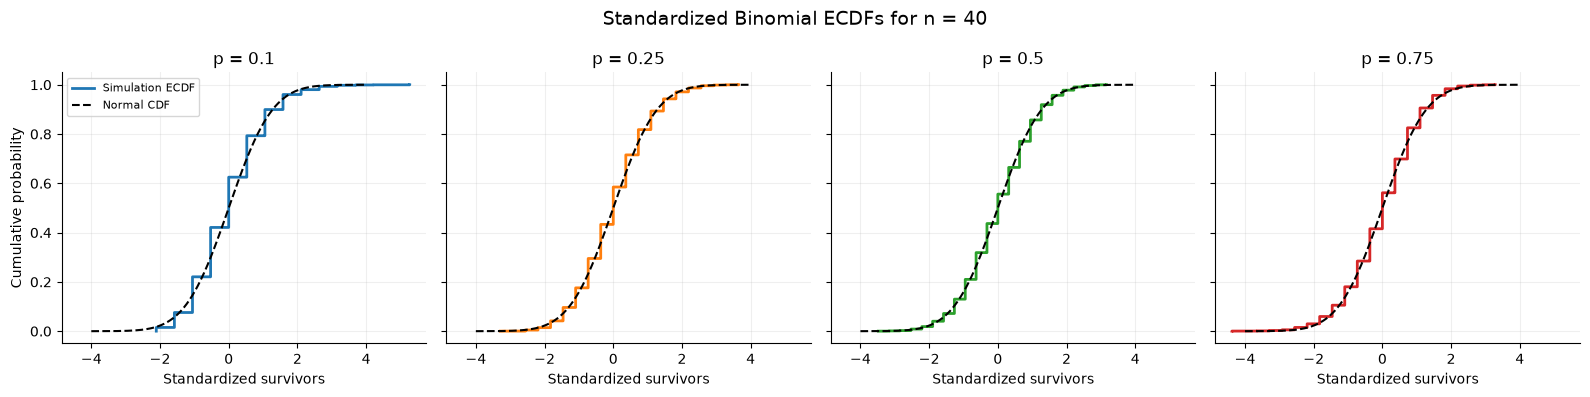

In [31]:
n = 40
b = 5_000

p_values = [0.10, 0.25, 0.50, 0.75]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

normal = stats.norm(0, 1) 
grid = np.linspace(-4, 4, 500)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4), sharex=True, sharey=True)

for ax, p, color in zip(axes, p_values, colors):
    
    counts = rng.binomial(n, p, size=b)

    z_binom = (
        counts - n * p
    ) / np.sqrt(n * p * (1 - p))

    x, y = ecdf_xy(z_binom)

    ax.step(x, y, where="post", color=color, linewidth=2, label="Simulation ECDF")

    ax.plot(grid, normal.cdf(grid), color="black", linestyle="--", linewidth=1.5, label="Normal CDF")

    ax.set_title(f"p = {p}")
    ax.set_xlabel("Standardized survivors")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Cumulative probability")
axes[0].legend(fontsize=8)

fig.suptitle(f"Standardized Binomial ECDFs for n = {n}", fontsize=14)

plt.tight_layout()
plt.show()

The higher the p-value, the more accurate the Simulation ECDF is compared to the Normal CDF line. With that said, the results change at a fairly low level. When we look at the graph p = 0.1, it is clearly slightly less accurate than the other graphs, but p = 0.5 and p = 0.75, there is nearly no change.

**Question 3: Used AI to adjust my code I had already made so that there were four graphs next to eachother that are comparable, rather than four large graphs that were all the same color.**

**Q5.**

We're going to draw a sample of values, sort them, and track a particular rank. This is particularly useful for
understanding extreme events: We might be interested in the behavior of the biggest storm or earthquake
each year, but be working with a dataset about storms in general over 25 or 50 years.
1. Draw K=20 values from Uniform[0, 1].
2. Sort them by size from smallest to largest.
3. Record the largest value.
4. Repeat n times and plot the ECDF.
5. Repeat the previous steps for each rank from 1 to K.
6. What distribution(s) does this process generate? How does the distribution depend on the rank?

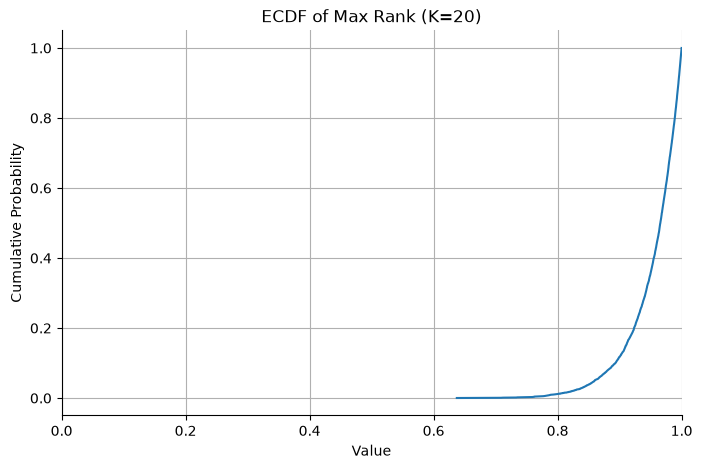

In [42]:
K = 20
n = 5000
values = []

for _ in range(n):
    draws = np.random.rand(K)
    draws = np.sort(draws)
    value = draws[-1]
    values.append(value)

ecdf = ECDF(values)

plt.plot(ecdf.x, ecdf.y, label='Simulated ECDF')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.title('ECDF of Max Rank (K=20)')
plt.xlim((0, 1))
plt.grid(True)
plt.show()

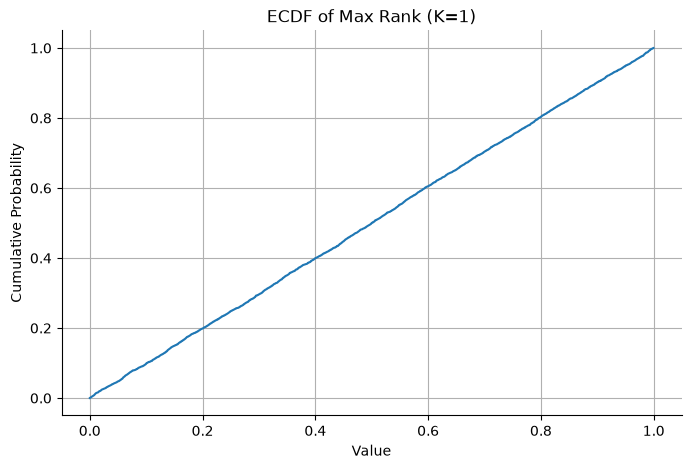

In [ ]:
K = 1
n = 5000
values = []

for _ in range(n):
    draws = np.random.rand(K)
    draws = np.sort(draws)
    value = draws[-1]
    values.append(value)

ecdf = ECDF(values)

plt.plot(ecdf.x, ecdf.y, label='Simulated ECDF')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.title('ECDF of Max Rank (K=1)')
plt.grid(True)
plt.show()

The ECDF seems to follow a beta distribution with beta = 1, and alpha scaling with K. When K = 1, the ECDF is linear, but as K increases, the curve gets pulled more and more down and to the right.


**Q8.**

Imagine a toy model of a collection of particles constantly colliding and exchanging energy, while the total amount of energy in the system remains fixed. No particle keeps its energy forever: repeated random exchanges eventually produce a stable distribution even though every individual particle continues to change.

1. Initialize `n = 1_000` particles with energy $E_i=1$.
2. Randomly choose two particles $i$ and $j$. Add their energies, $ E = E_i + E_j$ .
3. Draw a uniformly distributed number from between 0 and 1, $u$ and redistribute the energy: $ E_i = uE$ and $E_j=(1-u)E. $
4. Repeat this random exchange `b=1_000_000` times.
5. Record the final energies of all particles and plot their ECDF.
6. What distribution does this simulation approach as $n$ becomes large?
7. How does the distribution change if you increase or decrease the initial energy for each particle?

In [33]:
n = 1000
b = 1000000

particles = np.zeros(n) + 1

<Axes: xlabel='Particle Energy', ylabel='Proportion'>

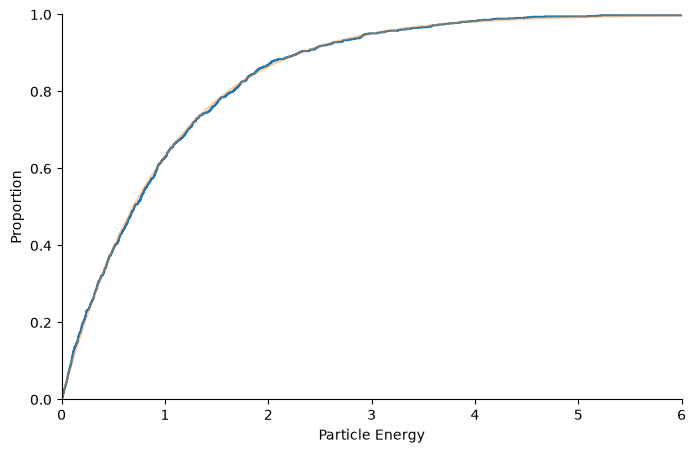

In [34]:
for _ in range(b):
    i = random.randint(0, n - 1)
    j = random.randint(0, n - 1)

    # Just make sure that i =/= j
    while i == j:
        j = random.randint(0, n - 1)

    E = particles[i] + particles[j]

    u = random.random()

    particles[i] = u * E
    particles[j] = (1 - u) * E

sns.ecdfplot(data=particles)
plt.xlabel('Particle Energy')
plt.xlim((0, 6))

# First order step response
x = np.linspace(0, 6, num=100)
y = 1 - np.exp(-x)
sns.lineplot(x=x, y=y, alpha=0.4)

The ECDF plot seems to have a similar shape to an inverse tangent curve, or a first order step response plot. Plotting a first order step response curve (1 - e^(-x)) over top of the ECDF shows a very good match to the experimental data, indicating that F(x) = 1 - e^-x.

Since f(x) = F'(x), we then know that the PDF is e^-x

Text(0.5, 0, 'Particle Energy')

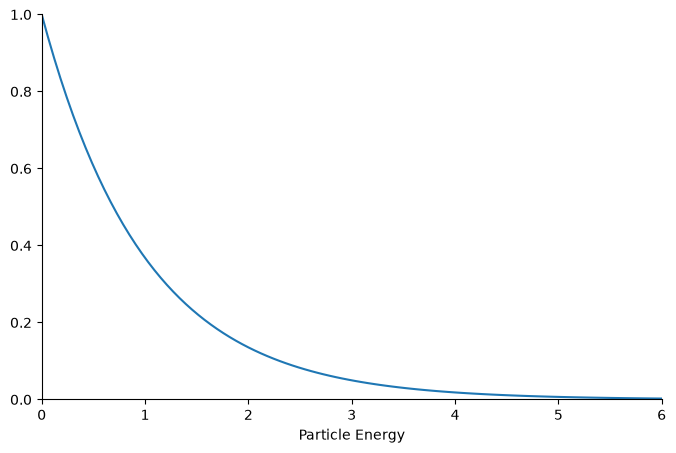

In [35]:
# Plot the PDF
x = np.linspace(0, 6, num=100)
y = np.exp(-x)
sns.lineplot(x=x, y=y)
plt.xlim((0, 6))
plt.ylim((0, 1))
plt.xlabel('Particle Energy')

(0.0, 60.0)

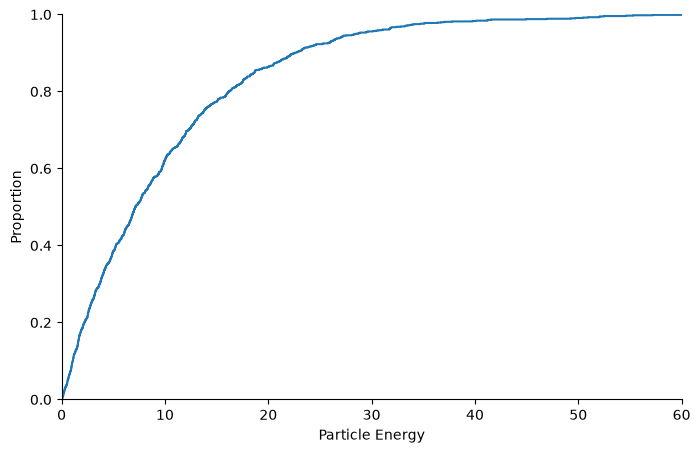

In [36]:
# Test different initial energies
particles = np.zeros(n) + 10

for _ in range(b):
    i = random.randint(0, n - 1)
    j = random.randint(0, n - 1)

    # Just make sure that i =/= j
    while i == j:
        j = random.randint(0, n - 1)

    E = particles[i] + particles[j]

    u = random.random()

    particles[i] = u * E
    particles[j] = (1 - u) * E

sns.ecdfplot(data=particles)
plt.xlabel('Particle Energy')
plt.xlim((0, 60))

Adjusting the initial energy simply stretches the ECDF plot horizontally. The underlying shape of the data is still the same. Larger initial energy -> the ECDF plot gets wider horizontally, and smaller initial energy -> the ECDF plot gets narrower horizontally.

### Google Usage
The resulting ECDF curve looked very similar to step response curves I learned about in my mechanical engineering undergrad. I didn't remember the exact formula for a first order step response curve, so I googled the equation and plugged it in to the plot above and it fit very well.